In [ ]:
# This code essentially funcitons the same way as the code from 07_cavity_flow.out.ipynb . The only difference that I made 
# Was I integrated jax.jnp into the workflow instead of numpy. This allows for faster gradient computations down the line
# Any time an array would be updated, instead of classc numpy indexing e.g u[1:-1, 1:-1] = ... , 
# I used jax's .at[].set() method which creates a new array with the updated values.

#next steps optimize top lid velocity 

In [ ]:
import jax
import jax.numpy as jnp
from matplotlib import pyplot, cm
%matplotlib inline

# Enable 64-bit floats — JAX defaults to 32-bit,
# but CFD needs the precision.
jax.config.update("jax_enable_x64", True)

nx = 41
ny = 41
nt = 1000
nit = 100  # matches NumPy notebook (which calls pressure_poisson twice per timestep × 50 each)
dx = 1.0 / (nx - 1)
dy = 1.0 / (ny - 1)

# np.linspace → jnp.linspace, same API
x = jnp.linspace(0, 1, nx)
y = jnp.linspace(0, 1, ny)
Y, X = jnp.meshgrid(x, y)   # same transposition as before

rho = 1.0
nu  = 0.1
dt  = 0.001

# np.zeros → jnp.zeros, same API
u = jnp.zeros((nx, ny))
v = jnp.zeros((nx, ny))
p = jnp.zeros((nx, ny))

In [ ]:
def build_up_b(b, rho, dt, u, v, dx, dy):
    interior = (rho * (
        1 / dt * (
            (u[2:, 1:-1] - u[0:-2, 1:-1]) / (2 * dx) +
            (v[1:-1, 2:] - v[1:-1, 0:-2]) / (2 * dy)
        ) -
        ((u[2:, 1:-1] - u[0:-2, 1:-1]) / (2 * dx))**2 -
        2 * ((u[1:-1, 2:] - u[1:-1, 0:-2]) / (2 * dy) *
             (v[2:, 1:-1] - v[0:-2, 1:-1]) / (2 * dx)) -
        ((v[1:-1, 2:] - v[1:-1, 0:-2]) / (2 * dy))**2
    ))

    b = b.at[1:-1, 1:-1].set(interior)  # ← the only change from NumPy
    return b

In [ ]:
def pressure_poisson(p, dx, dy, b):
    for _ in range(nit):
        pn = p   # In JAX, this is safe — p is immutable.
                 # When we do p.at[...].set() below, it creates new array
                 # to the old one. No .copy() needed.

        # 5-point Laplacian stencil — math unchanged
        p = p.at[1:-1, 1:-1].set(
            (
                (pn[2:, 1:-1] + pn[0:-2, 1:-1]) * dy**2 +
                (pn[1:-1, 2:] + pn[1:-1, 0:-2]) * dx**2
            ) / (2 * (dx**2 + dy**2))
            - dx**2 * dy**2 / (2 * (dx**2 + dy**2)) * b[1:-1, 1:-1]
        )

        # Neumann BCs — all six lines become .at[].set()
        p = p.at[-1, :].set(p[-2, :])   # dp/dx = 0, right wall
        p = p.at[:, 0].set(p[:, 1])     # dp/dy = 0, bottom wall
        p = p.at[0, :].set(p[1, :])     # dp/dx = 0, left wall
        p = p.at[:, -1].set(p[:, -2])   # dp/dy = 0, top wall
        p = p.at[0, 0].set(0.0)         # pin corner to fix uniqueness

    return p

In [ ]:
def cavity_flow(nt, u, v, dt, dx, dy, p, rho, nu,
                lid_velocity=1.0):   # <-- note: lid_velocity is already a parameter!
                                     # This is how you'll hook autodiff in later.
    b = jnp.zeros((nx, ny))

    for _ in range(nt):
        un = u   # safe in JAX — immutable arrays, no .copy() needed
        vn = v

        b = build_up_b(b, rho, dt, u, v, dx, dy)
        p = pressure_poisson(p, dx, dy, b)

        # --- u-momentum update (math identical to NumPy version) --

        
# .at.set() for jnp. Updating momentmum horizontally and vertically
        u = u.at[1:-1, 1:-1].set(
            un[1:-1, 1:-1]
            - un[1:-1, 1:-1] * dt / dx * (un[1:-1, 1:-1] - un[0:-2, 1:-1])
            - vn[1:-1, 1:-1] * dt / dy * (un[1:-1, 1:-1] - un[1:-1, 0:-2])
            - dt / (2 * rho * dx) * (p[2:, 1:-1] - p[0:-2, 1:-1])
            + nu * (
                dt / dx**2 * (un[2:, 1:-1] - 2*un[1:-1, 1:-1] + un[0:-2, 1:-1])
              + dt / dy**2 * (un[1:-1, 2:] - 2*un[1:-1, 1:-1] + un[1:-1, 0:-2])
            )
        )
# .at.sest() for jnp
        # --- v-momentum update ---
        v = v.at[1:-1, 1:-1].set(
            vn[1:-1, 1:-1]
            - un[1:-1, 1:-1] * dt / dx * (vn[1:-1, 1:-1] - vn[0:-2, 1:-1])
            - vn[1:-1, 1:-1] * dt / dy * (vn[1:-1, 1:-1] - vn[1:-1, 0:-2])
            - dt / (2 * rho * dy) * (p[1:-1, 2:] - p[1:-1, 0:-2])
            + nu * (
                dt / dx**2 * (vn[2:, 1:-1] - 2*vn[1:-1, 1:-1] + vn[0:-2, 1:-1])
              + dt / dy**2 * (vn[1:-1, 2:] - 2*vn[1:-1, 1:-1] + vn[1:-1, 0:-2])
            )
        )

# .at.set() for jnp

        # --- Velocity boundary conditions ---
        u = u.at[:, 0].set(0.0)           # left wall
        u = u.at[0, :].set(0.0)           # bottom wall
        u = u.at[-1, :].set(0.0)          # right wall
        u = u.at[:, -1].set(lid_velocity) # TOP LID ← will be optimization target later

        v = v.at[:, 0].set(0.0)
        v = v.at[:, -1].set(0.0)
        v = v.at[0, :].set(0.0)
        v = v.at[-1, :].set(0.0)

    return u, v, p

Text(0, 0.5, 'Y')

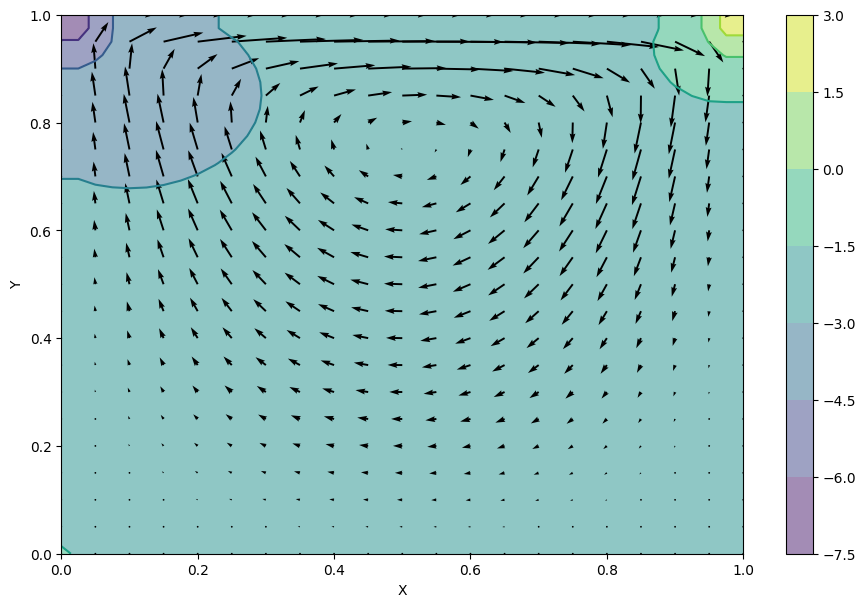

In [ ]:
# np --> jnp, same API

#1.

#convert these to np, #save arrays to pickle 
#np.linalg.norm(u_jax-u_np)
#plot np.abs(u_jax-u_np)
# ||x jax- xnp || = e1^2 + e2^2 + ....
# add up all pointwise errors

#2. make lid velocity a funciton of time sine wave (0.5-1.5) v(t) = sin(t)
#disicretise sin waves in to actions a
# compute dL/da 
#Loss = drag which is proportional to du/dy (sum du/dy along the cavity surface)
#if challengeing , make loss velocity of random gridpoint in cavity domain.

#3.
# points in sin wave move up and down
#lid velocity = a1sin(k1t) + a2sin(k2t) + ... + 1
#try to normalize this
#find which lid motion will miinize drag

#optimize drag with this




u = jnp.zeros((nx, ny))
v = jnp.zeros((nx, ny))
p = jnp.zeros((nx, ny))

#same as before
u_sol, v_sol, p_sol = cavity_flow(nt, u, v, dt, dx, dy, p, rho, nu)

fig = pyplot.figure(figsize=(11, 7), dpi=100)
pyplot.contourf(X, Y, p_sol, alpha=0.5, cmap=cm.viridis)
pyplot.colorbar()
pyplot.contour(X, Y, p_sol, cmap=cm.viridis)
pyplot.quiver(X[::2, ::2], Y[::2, ::2], u_sol[::2, ::2], v_sol[::2, ::2])
pyplot.xlabel('X')
pyplot.ylabel('Y')

#conv